In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

C:\Users\admin\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


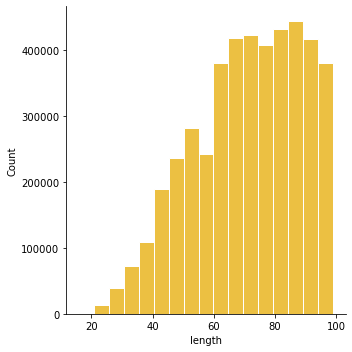

In [3]:
df = pd.read_csv('../pre-calculated_data/smorf_mapped_length.tsv',names=['length'])
sns.displot(data=df,x='length',color='#e6ab02',binwidth=5,edgecolor='white')

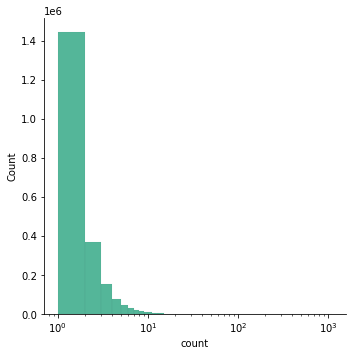

In [5]:
#too large to show here
#df = pd.read_csv('cluster_count.tsv',sep = '\t',names=['cluster','count','rep','seqs'])
#g=sns.displot(data=df,x='count',color='#1b9e77',binwidth=1)
#g.set(xscale="log")

In [6]:
# plot top 20 pfam
df = pd.read_csv('../pre-calculated_data/all.macrel.mapped.smorfs_dedup_cdd_tcov_family_bg_info_A_C_group.tsv',sep='\t')
df = df.sort_values('GMSC_count',ascending=False)
df = df[:15]
df

,accession,clan,clan_description,PSSM_Id,GMSC_count,GMSC_fraction,short_name,description,PSSM_Length,clan_id,short_description,group
0,8281,HTH,Helix-turn-helix clan,400535,7473,0.005510,Sigma70_r4_2,"Sigma-70, region 4. Region 4 of sigma-70 like ...",54,CL0123,"Sigma-70, region 4",Helix-turn-helix clan
1,4545,HTH,Helix-turn-helix clan,427999,7254,0.005349,Sigma70_r4,"Sigma-70, region 4. Region 4 of sigma-70 like ...",50,CL0123,"Sigma-70, region 4",Helix-turn-helix clan
2,196,HTH,Helix-turn-helix clan,425517,6656,0.004908,GerE,"Bacterial regulatory proteins, luxR family.",57,CL0123,"Bacterial regulatory proteins, luxR family",Helix-turn-helix clan
3,2954,HTH,Helix-turn-helix clan,427077,6232,0.004595,HTH_8,"Bacterial regulatory protein, Fis family.",40,CL0123,"Bacterial regulatory protein, Fis family",Helix-turn-helix clan
4,313,OB,OB fold,278729,5943,0.004382,CSD,'Cold-shock' DNA-binding domain.,66,CL0021,'Cold-shock' DNA-binding domain,OB fold
5,12399,P-loop_NTPase,P-loop containing nucleoside triphosphate hydr...,432527,4812,0.003548,BCA_ABC_TP_C,Branched-chain amino acid ATP-binding cassette...,23,CL0023,Branched-chain amino acid ATP-binding cassette...,P-loop containing nucleoside triphosphate hydr...
6,486,HTH,Helix-turn-helix clan,425712,4154,0.003063,Trans_reg_C,"Transcriptional regulatory protein, C terminal.",77,CL0123,"Transcriptional regulatory protein, C terminal",Helix-turn-helix clan
7,2597,Ubiquitin,Ubiquitin superfamily,396932,4107,0.003028,ThiS,ThiS family. ThiS (thiaminS) is a 66 aa protei...,74,CL0072,ThiS family,Ubiquitin superfamily
8,1381,HTH,Helix-turn-helix clan,396104,3865,0.002850,HTH_3,Helix-turn-helix. This large family of DNA bin...,55,CL0123,Helix-turn-helix,Helix-turn-helix clan
9,550,PP-binding,ACP-like superfamily,425746,3590,0.002647,PP-binding,Phosphopantetheine attachment site. A 4'-phosp...,62,CL0314,Phosphopantetheine attachment site,ACP-like superfamily


C:\Users\admin\anaconda3\lib\_collections_abc.py:832: MatplotlibDeprecationWarning: 
The savefig.jpeg_quality rcparam was deprecated in Matplotlib 3.3 and will be removed two minor releases later.
  self[key] = other[key]
C:\Users\admin\anaconda3\lib\_collections_abc.py:832: MatplotlibDeprecationWarning: 
The savefig.jpeg_quality rcparam was deprecated in Matplotlib 3.3 and will be removed two minor releases later.
  self[key] = other[key]


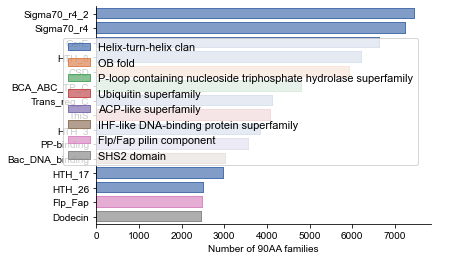

In [8]:
import seaborn.objects as so

f, ax = plt.subplots()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

p = (
    so.Plot(df, x="GMSC_count",y="short_name", color="group")
    .add(so.Bar())
    .label(x="Number of 90AA families", y="",color="")
    .theme({"axes.facecolor": "w", "axes.edgecolor": "black",'axes.linewidth':0.5})
)
p.on(ax).show()

In [10]:
df = pd.read_csv('../pre-calculated_data/smorf_tax.csv')
df

,Taxonomy,Super_kingdom,Phylum,Class,Order,Family,Genus,Species,No_rank
0,mags,0.000642,0.000872,0.004208,0.031135,0.257661,0.692166,0.007081,0.006235
1,contigs,0.090718,0.060234,0.075997,0.146570,0.323812,0.254983,0.047589,0.000097
2,all,0.078743,0.052327,0.066330,0.130710,0.314031,0.310158,0.047073,0.000628


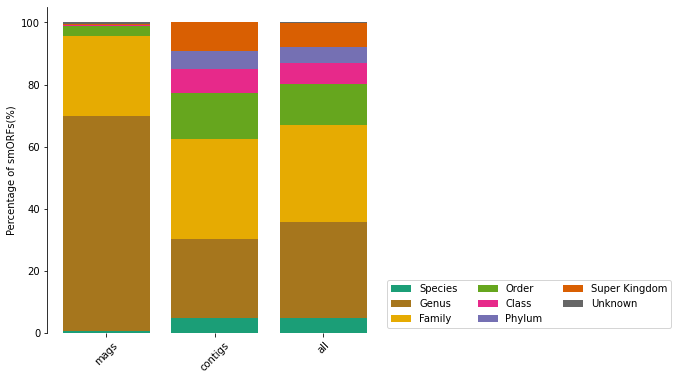

In [11]:
fig, ax = plt.subplots(figsize=(6,6))
x = df['Taxonomy']
y8 = df['No_rank'] *100
y7 = df['Super_kingdom'] *100
y6 = df['Phylum'] *100
y5 = df['Class'] *100
y4 = df['Order'] *100
y3 = df['Family'] *100
y2 = df['Genus'] *100
y1 = df['Species'] *100

plt.bar(x,y1,color='#1b9e77',label='Species')
plt.bar(x,y2,bottom=y1,color='#a6761d',label='Genus')
plt.bar(x,y3,bottom=y1+y2,color='#e6ab02',label='Family')
plt.bar(x,y4,bottom=y1+y2+y3,color='#66a61e',label='Order')
plt.bar(x,y5,bottom=y1+y2+y3+y4,color='#e7298a',label='Class')
plt.bar(x,y6,bottom=y1+y2+y3+y4+y5,color='#7570b3',label='Phylum')
plt.bar(x,y7,bottom=y1+y2+y3+y4+y5+y6,color='#d95f02',label='Super Kingdom')
plt.bar(x,y8,bottom=y1+y2+y3+y4+y5+y6+y7,color='#666666',label='Unknown')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
plt.xticks(rotation=45)
plt.ylabel('Percentage of smORFs(%)')
plt.legend(loc=3,bbox_to_anchor=(1,0),ncol=3)